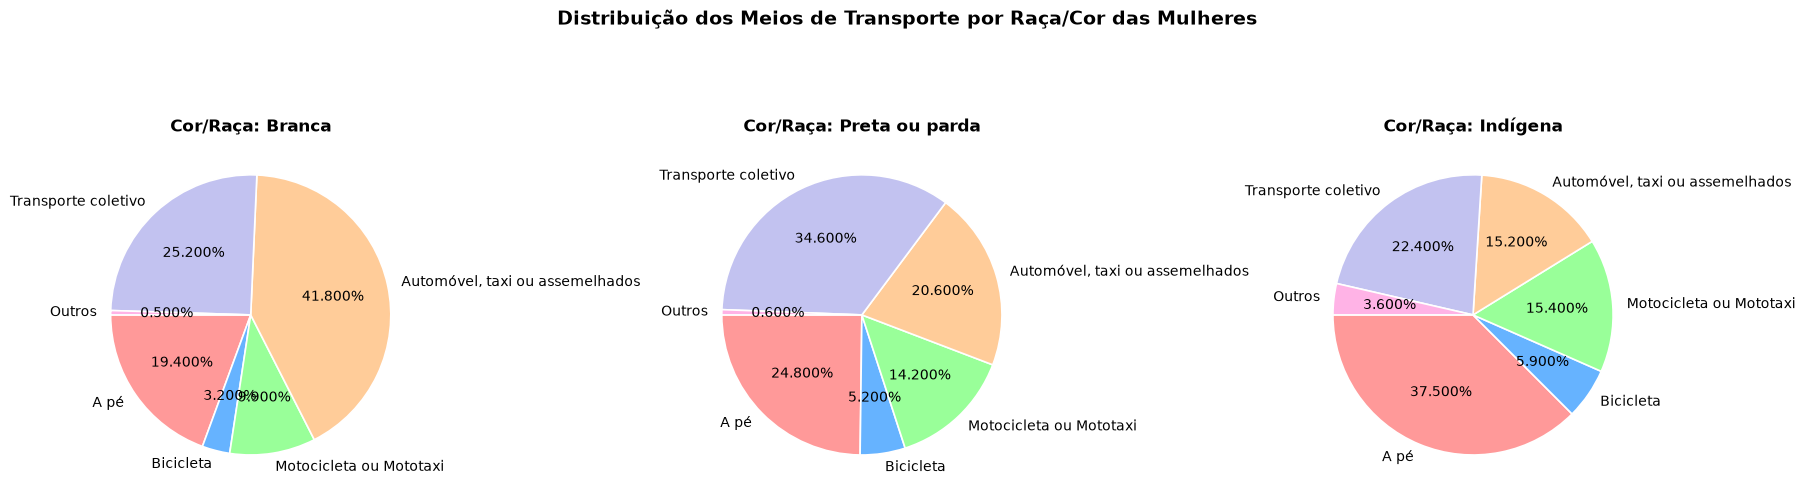

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

caminho_arquivo = 'Tabela_13_Meio_de_transporte.xlsx'

# O parâmetro header=1 ajusta a primeira linha como cabeçalho
df_grafico = pd.read_excel(
    caminho_arquivo, sheet_name='Exemplo gráfico Brasil', header=1
)

TAMANHO = (18, 6)
fig, axes = plt.subplots(1, 3, figsize=TAMANHO)
cores = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0', '#ffb3e6']
grupos = ['Branca', 'Preta ou parda', 'Indígena']

for i, col in enumerate(grupos):
    axes[i].pie(
        df_grafico[col],
        labels=df_grafico['Meio de transporte/cor ou raça'],
        autopct='%1.3f%%',
        startangle=180,
        colors=cores,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.2},
    )
    axes[i].set_title(f'Cor/Raça: {col}', fontsize=12, fontweight='bold')

plt.suptitle(
    'Distribuição dos Meios de Transporte por Raça/Cor das Mulheres',
    fontsize=14,
    fontweight='bold',
)
plt.tight_layout()
plt.savefig('grafico_transporte.png', dpi=300)
plt.show()

In [7]:
import pandas as pd

caminho_arquivo = 'Tabela_13_Meio_de_transporte.xlsx'


df_raw = pd.read_excel(caminho_arquivo, sheet_name='BR GR UF MU')

col_names = ['Localidade']
for raca in ['Branca', 'Preta ou Parda', 'Indígena']:
    for transporte in [
        'A pé',
        'Bicicleta',
        'Motocicleta ou Mototaxi',
        'Automóvel, taxi ou assemelhados',
        'Transporte coletivo',
        'Outros',
    ]:
        col_names.append(f'{raca} - {transporte}')

df_raw.columns = col_names
df_data = df_raw.iloc[2:].copy()
df_data['Localidade'] = df_data['Localidade'].astype(str).str.strip()

for col in col_names[1:]:
    df_data[col] = pd.to_numeric(df_data[col], errors='coerce').fillna(0)

ufs = [
    'Rondônia',
    'Acre',
    'Amazonas',
    'Roraima',
    'Pará',
    'Amapá',
    'Tocantins',
    'Maranhão',
    'Piauí',
    'Ceará',
    'Rio Grande do Norte',
    'Paraíba',
    'Pernambuco',
    'Alagoas',
    'Sergipe',
    'Bahia',
    'Minas Gerais',
    'Espírito Santo',
    'Rio de Janeiro',
    'São Paulo',
    'Paraná',
    'Santa Catarina',
    'Rio Grande do Sul',
    'Mato Grosso do Sul',
    'Mato Grosso',
    'Goiás',
    'Distrito Federal',
]


df_ufs = df_data[df_data['Localidade'].isin(ufs)].copy()
print('--- LISTA DOS ESTADOS ---')
print(df_ufs['Localidade'].unique())


df_melted_ufs = df_ufs.melt(
    id_vars=['Localidade'], var_name='Grupo', value_name='Percentual'
)
df_melted_ufs[['Raca', 'Transporte']] = df_melted_ufs['Grupo'].str.split(
    ' - ', expand=True
)
df_tc_uf = (
    df_melted_ufs[df_melted_ufs['Transporte'] == 'Transporte coletivo']
    .groupby('Localidade')['Percentual']
    .mean()
    .reset_index()
)

estado_mais_tc = df_tc_uf.loc[df_tc_uf['Percentual'].idxmax()]['Localidade']
estado_menos_tc = df_tc_uf.loc[df_tc_uf['Percentual'].idxmin()]['Localidade']


regioes = ['Brasil', 'Norte', 'Nordeste', 'Sudeste', 'Sul', 'Centro-oeste']
df_mun = df_data[~df_data['Localidade'].isin(regioes + ufs)].copy()

df_melted_mun = df_mun.melt(
    id_vars=['Localidade'], var_name='Grupo', value_name='Percentual'
)
df_melted_mun[['Raca', 'Transporte']] = df_melted_mun['Grupo'].str.split(
    ' - ', expand=True
)


df_bic_mun = (
    df_melted_mun[df_melted_mun['Transporte'] == 'Bicicleta']
    .groupby('Localidade')['Percentual']
    .mean()
    .reset_index()
)
cidade_mais_bike = df_bic_mun.loc[df_bic_mun['Percentual'].idxmax()][
    'Localidade'
]


df_car_mun = (
    df_melted_mun[
        df_melted_mun['Transporte'] == 'Automóvel, taxi ou assemelhados'
    ]
    .groupby('Localidade')['Percentual']
    .mean()
    .reset_index()
)
cidade_mais_carro = df_car_mun.loc[df_car_mun['Percentual'].idxmax()][
    'Localidade'
]

print('\n--- RESULTADOS DAS QUESTÕES ---')
print(
    f'Estado com mais mulheres utilizando transporte coletivo: {estado_mais_tc}'
)
print(
    f'Estado com menos mulheres utilizando transporte coletivo: {estado_menos_tc}'
)
print(f'Cidade com mais mulheres andando de bicicleta: {cidade_mais_bike}')
print(f'Cidade com mais mulheres utilizando carro: {cidade_mais_carro}')

--- LISTA DOS ESTADOS ---
<StringArray>
[           'Rondônia',                'Acre',            'Amazonas',
             'Roraima',                'Pará',               'Amapá',
           'Tocantins',            'Maranhão',               'Piauí',
               'Ceará', 'Rio Grande do Norte',             'Paraíba',
          'Pernambuco',             'Alagoas',             'Sergipe',
               'Bahia',        'Minas Gerais',      'Espírito Santo',
      'Rio de Janeiro',           'São Paulo',              'Paraná',
      'Santa Catarina',   'Rio Grande do Sul',  'Mato Grosso do Sul',
         'Mato Grosso',               'Goiás',    'Distrito Federal']
Length: 27, dtype: str

--- RESULTADOS DAS QUESTÕES ---
Estado com mais mulheres utilizando transporte coletivo: Rio de Janeiro
Estado com menos mulheres utilizando transporte coletivo: Rondônia
Cidade com mais mulheres andando de bicicleta: Lagoa Grande (MG)
Cidade com mais mulheres utilizando carro: Bom Jesus (SC)


In [10]:
#"Diferenças por raça:
 #Carro: Brancas usam 21,2% a mais que Pretas/Pardas.
 #Transporte coletivo: Pretas/Pardas usam 9,4% a mais que Brancas.
  #A pé:Indígenas andam 18,1% a mais a pé que Brancas.
  #Moto: Indígenas usam 5,5% a mais que Brancas.
  #Bicicleta: Pretas/Pardas usam 2% a mais que Brancas.

#Parte 2 (Localidades):**
#Estado com mais transporte coletivo: Rio de Janeiro
#Estado com menos transporte coletivo: Rondônia
#Cidade com mais bicicleta: Lagoa Grande (MG)
#Cidade com mais carro: Bom Jesus (SC)

